In [23]:
%load_ext autoreload
%autoreload 2

import numpy as np
from math import sqrt
import importlib

import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt

from causal_graph_comparison.subsample import subsample_outputs
from causal_graph_comparison import *
import causal_graph_comparison.utils as utils
importlib.reload(utils)
flatten_temporal_adjacency_graph = utils.flatten_temporal_adjacency_graph

from climatem.data_loader.causal_datamodule import CausalClimateDataModule
import torch

import gadjid
from gadjid import example, ancestor_aid, oset_aid, parent_aid, shd, sid
from causal_graph_comparison.utils import binarize_array


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
N_MODES = 4
TAU_MAX = 5
LAT = 40
LON = 40
N_SAMPLES = 995

In [5]:
# Step 1: Load the data
lstm_output_50steps = np.load("../outputs/test_results-lstm-savar-1000samples-50steps.npz")

In [6]:
outputs_50steps = lstm_output_50steps["outputs"]
targets_50steps = lstm_output_50steps["target"]
inputs_50steps = lstm_output_50steps["inputs"]

print("MLP output shape: ", outputs_50steps.shape)
print("MLP target shape: ", targets_50steps.shape)
print("MLP inputs shape: ", inputs_50steps.shape)

MLP output shape:  (50, 949, 1600)
MLP target shape:  (50, 949, 1600)
MLP inputs shape:  (949, 5, 1600)


In [7]:
# Spatial subsampling of outputs for dimensionality 50 timesteps

samples_50steps = inputs_50steps.shape[0]
timesteps_in_50steps = inputs_50steps.shape[1]
timesteps_out_50steps = outputs_50steps.shape[0]
n_modes_per_side = int(sqrt(N_MODES))

subsampled_inputs_50steps = np.zeros((samples_50steps, timesteps_in_50steps, n_modes_per_side, n_modes_per_side))
subsampled_outputs_50steps = np.zeros((samples_50steps, timesteps_out_50steps, n_modes_per_side, n_modes_per_side))
subsampled_targets_50steps = np.zeros((samples_50steps, timesteps_out_50steps, n_modes_per_side, n_modes_per_side))

for i in range(samples_50steps):
    subsampled_inputs_50steps[i, :, :, :] = subsample_outputs(inputs_50steps[i, :, :], N_MODES)
    subsampled_outputs_50steps[i, :, :, :] = subsample_outputs(outputs_50steps[:, i, :], N_MODES)
    subsampled_targets_50steps[i, :, :, :] = subsample_outputs(targets_50steps[:, i, :], N_MODES)

print("Shape of subsampled_inputs for 50 steps: ", subsampled_inputs_50steps.shape)
print("Shape of subsampled_outputs for 50 steps: ", subsampled_outputs_50steps.shape)
print("Shape of subsampled_targets for 50 steps: ", subsampled_targets_50steps.shape)

subsampled_inputs_50steps = subsampled_inputs_50steps.reshape(samples_50steps, 5, 4)
subsampled_outputs_50steps = subsampled_outputs_50steps.reshape(samples_50steps, 50, 4)
subsampled_targets_50steps = subsampled_targets_50steps.reshape(samples_50steps, 50, 4)

print("Shape of subsampled_inputs for 50 steps: ", subsampled_inputs_50steps.shape)
print("Shape of subsampled_outputs for 50 steps: ", subsampled_outputs_50steps.shape)
print("Shape of subsampled_targets for 50 steps: ", subsampled_targets_50steps.shape)

Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (5

In [8]:
# Create variable names for the modes
var_names = [f"mode_{i}" for i in range(N_MODES)]
dataframe = pp.DataFrame(subsampled_outputs_50steps, analysis_mode = 'multiple', var_names=var_names)
# dataframe = pp.DataFrame(data_and_targets[0], analysis_mode = 'single', var_names=var_names)

# ======= PLOT FOR 1 TIME STEP ONLY =======
# i = 0
# for member in dataframe.values.keys():
#     print("Member: ", member)
#     tp.plot_timeseries(selected_dataset = member, dataframe = dataframe)
#     plt.show()
#     i+=1
#     if i > 3:
#         break


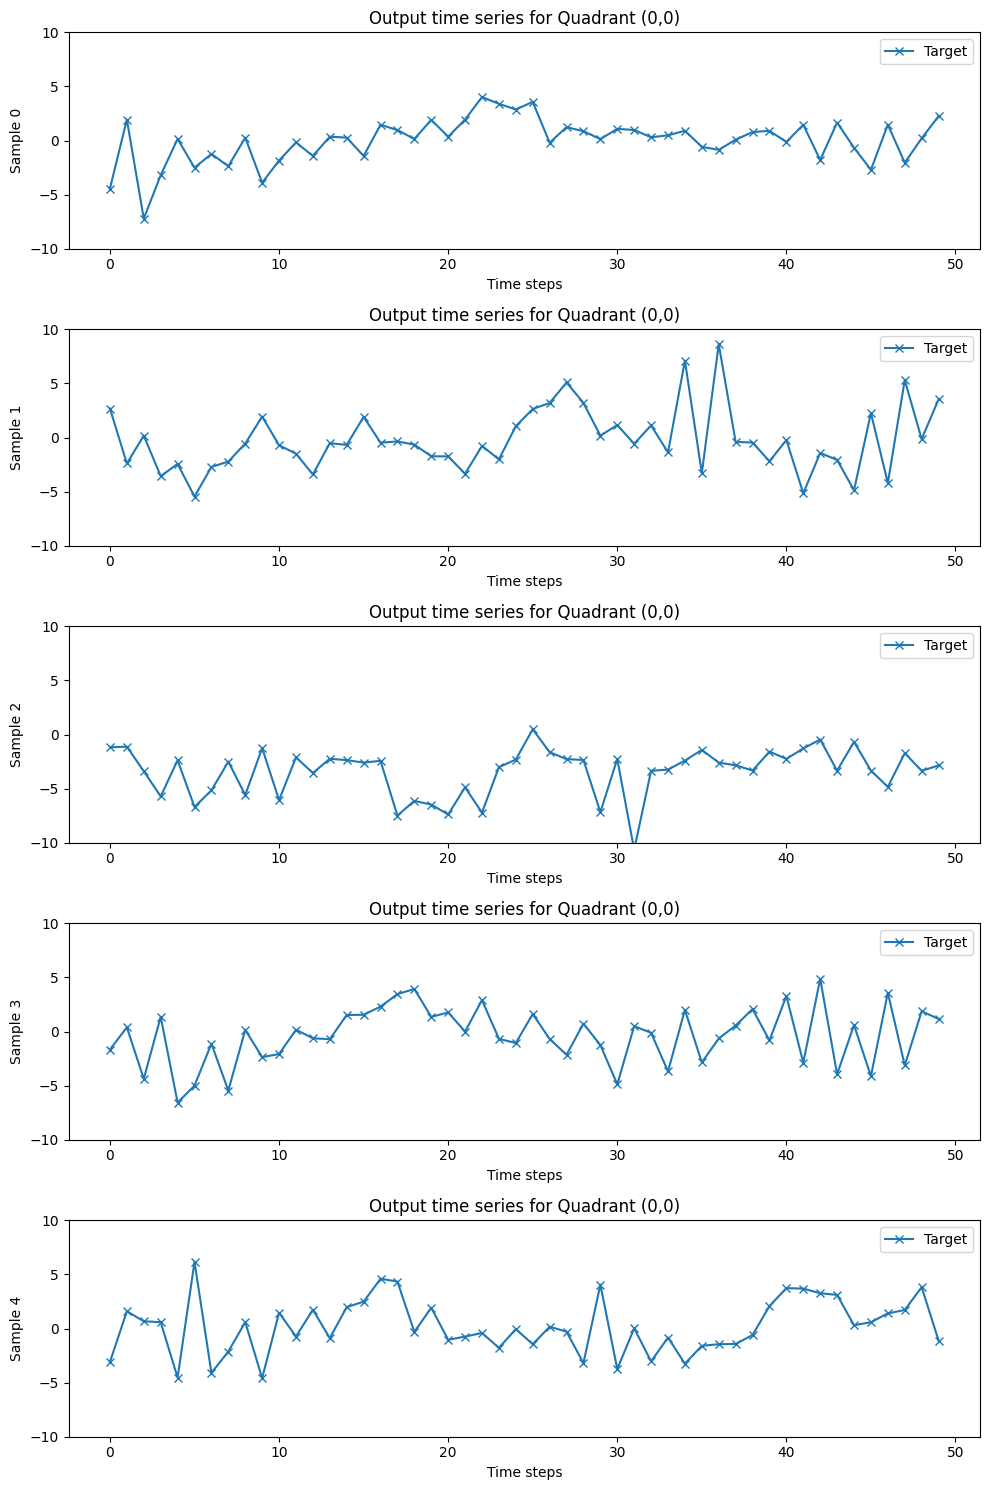

In [9]:
# Plot targets for 50 steps in quadrant 1 for the first 5 samples

y_values = subsampled_outputs_50steps.reshape(samples_50steps, 50, 2, 2)

# Plot targets and outputs for all quadrant 1
plt.figure(figsize=(10, 15))

# Find global min and max values across targets
all_values = []
for i in range(50):
    all_values.extend(y_values[0+i, :, 0, 0])
y_min, y_max = min(all_values), max(all_values)

y_min, y_max = -10, 10

for i in range(5):
    plt.subplot(5, 1, i+1)
    test_targets = y_values[0+i, :, 0, 0]

    # print(test_targets)
    
    # Create x-axis points for inputs and targets/outputs, shifted by i positions
    x_vals = np.arange(50)
    
    plt.plot(x_vals, test_targets, label="Target", marker='x')
    plt.ylabel(f"Sample {i}")
    plt.xlabel("Time steps")
    # plt.xticks(np.arange(50))  # Extended x-axis range to accommodate shifts
    plt.ylim(y_min, y_max)  # Set same y-axis limits for all subplots
    plt.title(f"Output time series for Quadrant ({0},{0})")
    plt.legend()

plt.tight_layout()
plt.show()



In [10]:
print (dataframe.M)
print (dataframe.N)
print (dataframe.T)

949
4
{0: 50, 1: 50, 2: 50, 3: 50, 4: 50, 5: 50, 6: 50, 7: 50, 8: 50, 9: 50, 10: 50, 11: 50, 12: 50, 13: 50, 14: 50, 15: 50, 16: 50, 17: 50, 18: 50, 19: 50, 20: 50, 21: 50, 22: 50, 23: 50, 24: 50, 25: 50, 26: 50, 27: 50, 28: 50, 29: 50, 30: 50, 31: 50, 32: 50, 33: 50, 34: 50, 35: 50, 36: 50, 37: 50, 38: 50, 39: 50, 40: 50, 41: 50, 42: 50, 43: 50, 44: 50, 45: 50, 46: 50, 47: 50, 48: 50, 49: 50, 50: 50, 51: 50, 52: 50, 53: 50, 54: 50, 55: 50, 56: 50, 57: 50, 58: 50, 59: 50, 60: 50, 61: 50, 62: 50, 63: 50, 64: 50, 65: 50, 66: 50, 67: 50, 68: 50, 69: 50, 70: 50, 71: 50, 72: 50, 73: 50, 74: 50, 75: 50, 76: 50, 77: 50, 78: 50, 79: 50, 80: 50, 81: 50, 82: 50, 83: 50, 84: 50, 85: 50, 86: 50, 87: 50, 88: 50, 89: 50, 90: 50, 91: 50, 92: 50, 93: 50, 94: 50, 95: 50, 96: 50, 97: 50, 98: 50, 99: 50, 100: 50, 101: 50, 102: 50, 103: 50, 104: 50, 105: 50, 106: 50, 107: 50, 108: 50, 109: 50, 110: 50, 111: 50, 112: 50, 113: 50, 114: 50, 115: 50, 116: 50, 117: 50, 118: 50, 119: 50, 120: 50, 121: 50, 122: 

In [11]:
# STEP 4: Learn causal graph using PCMCI+

# Initialize PCMCI+
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(),
    verbosity=2
)

# Run PCMCI+
results = pcmci.run_pcmciplus(
    tau_max=TAU_MAX,  # Maximum time lag
    tau_min=1,
    pc_alpha=0.01  # Significance level #TODO
)

n_gt_connections = 8 # TODO: get this from the GT causal graph in parameters csv file

# Extract results
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.01]
max_conds_dim = None
max_combinations = 1



## Variable mode_0

Iterating through pc_alpha = [0.01]:

# pc_alpha = 0.01 (1/1):

Testing condition sets of dimension 0:

    Link (mode_0 -1) -?> mode_0 (1/20):
    Subset 0: () gives pval = 0.00000 / val =  0.240
    No conditions of dimension 0 left.

    Link (mode_0 -2) -?> mode_0 (2/20):
    Subset 0: () gives pval = 0.00000 / val =  0.637
    No conditions of dimension 0 left.

    Link (mode_0 -3) -?> mode_0 (3/20):
    Subset 0: () gives pval = 0.00000 / val =  0.380
    No conditions of dimension 0 left.

    Link (mode_0 -4) -?> mode_0 (4/20):
    Subset 0: () gives pval = 0.00000 / val =  0.399
    No conditions of dimension 0 left.

    Link (mode_0 -5) -?> mode_0 (5/20):
    Subset 0: () gives pval = 0.00000 / val =  0.297
    No conditions of dimension 0 left.

    Link (mode_1 -

In [12]:
dataframe.values

{0: array([[-4.43456936,  3.62224054,  3.14439321, -5.28042316],
        [ 1.93655956,  2.06861401, -3.05367446, -0.54181862],
        [-7.21579933,  4.32107544, -3.77391171, -0.31268147],
        [-3.20516896,  0.18728366, -4.49287271, -5.96125937],
        [ 0.15147112, -1.52687967,  2.47716951, -3.28719568],
        [-2.51300788, -0.03231212, -3.32498169,  2.95625496],
        [-1.23693228, -3.46995902, -2.45232511, -6.34464502],
        [-2.3751545 , -2.2293098 ,  2.23290658,  1.1264993 ],
        [ 0.26976597,  0.113616  , -0.85543913, -4.88573503],
        [-3.89682364, -2.08781385, -0.44437525,  2.17946625],
        [-1.84752309,  2.54524064, -0.67390019, -3.81824923],
        [-0.17156176, -3.64382148, -0.76549298, -0.44100961],
        [-1.42484021, -0.02597676,  0.35065964,  0.62376362],
        [ 0.35710943, -3.32775283, -0.22098264, -4.63185596],
        [ 0.26777336, -2.15302992, -2.91649675,  0.20986152],
        [-1.42865682,  1.40531409, -1.59071803, -3.83535266],
     

In [13]:
# Keep only the top 2 incoming values for each mode
print(f"\nFiltering to keep only top 2 incoming values per mode...")

# Create a copy of the original val_matrix
filtered_val_matrix = val_matrix.copy()
filtered_graph = graph.copy()

# For each target mode (each of the 4 modes)
for target_mode in range(val_matrix.shape[0]):
    print(f"\nProcessing incoming connections to mode {target_mode}:")
    
    # Collect all incoming values to this target mode
    # We need row 'target_mode' from each of the 4 matrices
    incoming_values = []
    incoming_positions = []
    
    for source_mode in range(val_matrix.shape[0]):  # source modes
        for lag in range(val_matrix.shape[2]):      # time lags
            value = val_matrix[source_mode, target_mode, lag]
            if value != 0:  # Only consider non-zero values
                incoming_values.append(abs(value))
                incoming_positions.append((source_mode, target_mode, lag))
    
    # Find the top 2 incoming connections
    if len(incoming_values) > 0:
        # Get indices of top 2 values
        top_indices = np.argsort(incoming_values)[-2:]
        
        print(f"Top 2 incoming connections to mode {target_mode}:")
        for idx in top_indices:
            source_mode, target_mode, lag = incoming_positions[idx]
            value = val_matrix[source_mode, target_mode, lag]
            print(f"  From mode {source_mode} to mode {target_mode} at lag {lag}: {value:.6f}")
    
    # Create a mask for all incoming connections to this target mode
    # Set all incoming connections to this target mode to 0/empty first
    for source_mode in range(val_matrix.shape[0]):
        for lag in range(val_matrix.shape[2]):
            filtered_val_matrix[source_mode, target_mode, lag] = 0
            filtered_graph[source_mode, target_mode, lag] = ""
    
    # Then restore only the top 2 incoming connections
    if len(incoming_values) > 0:
        for idx in top_indices:
            source_mode, target_mode, lag = incoming_positions[idx]
            filtered_val_matrix[source_mode, target_mode, lag] = val_matrix[source_mode, target_mode, lag]
            filtered_graph[source_mode, target_mode, lag] = graph[source_mode, target_mode, lag]

print(f"\nFiltered val_matrix shape: {filtered_val_matrix.shape}")
print(f"Total non-zero values in filtered matrix: {np.sum(filtered_val_matrix != 0)}")

# Print the filtered graph to see the remaining links
print(f"\nFiltered graph:")
print(filtered_graph)


Filtering to keep only top 2 incoming values per mode...

Processing incoming connections to mode 0:
Top 2 incoming connections to mode 0:
  From mode 2 to mode 0 at lag 4: 0.460135
  From mode 0 to mode 0 at lag 2: 0.560763

Processing incoming connections to mode 1:
Top 2 incoming connections to mode 1:
  From mode 2 to mode 1 at lag 1: -0.213049
  From mode 0 to mode 1 at lag 4: 0.329370

Processing incoming connections to mode 2:
Top 2 incoming connections to mode 2:
  From mode 0 to mode 2 at lag 5: 0.301538
  From mode 2 to mode 2 at lag 3: 0.384681

Processing incoming connections to mode 3:
Top 2 incoming connections to mode 3:
  From mode 3 to mode 3 at lag 3: 0.258351
  From mode 2 to mode 3 at lag 5: 0.595130

Filtered val_matrix shape: (4, 4, 6)
Total non-zero values in filtered matrix: 8

Filtered graph:
[[['' '' '-->' '' '' '']
  ['' '' '' '' '-->' '']
  ['' '' '' '' '' '-->']
  ['' '' '' '' '' '']]

 [['' '' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '']
  [''

In [14]:

print(f"\nPCMCI+ Results:")
print(f"Graph shape: {graph.shape}")
print(f"Value matrix shape: {val_matrix.shape}")
print(f"P-value matrix shape: {p_matrix.shape}")

# Print the discovered links
print(f"\nDiscovered causal links:")
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX):
            if graph[i, j, tau] != "":
                print(f"{var_names[i]} <-{graph[i, j, tau]}- {var_names[j]} (lag {tau+1})")


PCMCI+ Results:
Graph shape: (4, 4, 6)
Value matrix shape: (4, 4, 6)
P-value matrix shape: (4, 4, 6)

Discovered causal links:
mode_0 <--->- mode_0 (lag 2)
mode_0 <--->- mode_0 (lag 3)
mode_0 <--->- mode_1 (lag 3)
mode_0 <--->- mode_1 (lag 4)
mode_0 <--->- mode_1 (lag 5)
mode_0 <--->- mode_2 (lag 3)
mode_0 <--->- mode_2 (lag 4)
mode_0 <--->- mode_3 (lag 3)
mode_0 <--->- mode_3 (lag 4)
mode_1 <--->- mode_0 (lag 3)
mode_1 <--->- mode_1 (lag 3)
mode_1 <--->- mode_1 (lag 4)
mode_1 <--->- mode_2 (lag 2)
mode_2 <--->- mode_0 (lag 5)
mode_2 <--->- mode_1 (lag 2)
mode_2 <--->- mode_1 (lag 3)
mode_2 <--->- mode_2 (lag 2)
mode_2 <--->- mode_2 (lag 3)
mode_2 <--->- mode_2 (lag 4)
mode_2 <--->- mode_3 (lag 3)
mode_3 <--->- mode_0 (lag 2)
mode_3 <--->- mode_0 (lag 3)
mode_3 <--->- mode_1 (lag 2)
mode_3 <--->- mode_1 (lag 4)
mode_3 <--->- mode_2 (lag 2)
mode_3 <--->- mode_2 (lag 4)
mode_3 <--->- mode_2 (lag 5)
mode_3 <--->- mode_3 (lag 2)
mode_3 <--->- mode_3 (lag 3)
mode_3 <--->- mode_3 (lag 4)


In [15]:
# Step 5: Analyze mode relationships

print(f"\nStep 5: Analyzing mode relationships...")

# Calculate correlations between modes
correlations = np.corrcoef(subsampled_outputs_50steps.reshape(-1, 4).T)

print(f"\nCorrelation matrix between modes:")
print(pd.DataFrame(correlations, index=var_names, columns=var_names))

# Count causal links per mode
print(f"\nCausal link counts per mode:")
for i, mode in enumerate(var_names):
    incoming = np.sum(graph[i, :, :] != "")
    outgoing = np.sum(graph[:, i, :] != "")
    print(f"{mode}: {incoming} incoming, {outgoing} outgoing links")



Step 5: Analyzing mode relationships...

Correlation matrix between modes:
          mode_0    mode_1    mode_2    mode_3
mode_0  1.000000  0.110328  0.206704  0.044172
mode_1  0.110328  1.000000  0.240240  0.086540
mode_2  0.206704  0.240240  1.000000 -0.020820
mode_3  0.044172  0.086540 -0.020820  1.000000

Causal link counts per mode:
mode_0: 10 incoming, 7 outgoing links
mode_1: 4 incoming, 9 outgoing links
mode_2: 9 incoming, 11 outgoing links
mode_3: 11 incoming, 7 outgoing links



Step 6: Plotting causal graph...


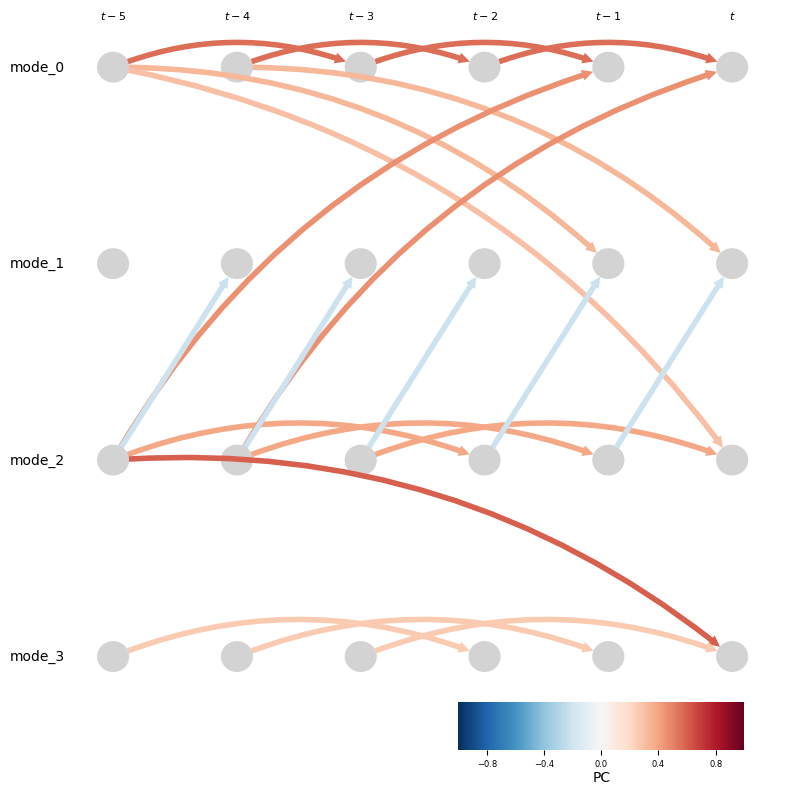

In [16]:
# Step 6: Plot causal graph
print(f"\nStep 6: Plotting causal graph...")

# Plot graph for each lag
tp.plot_time_series_graph(
    graph = filtered_graph,
    val_matrix=filtered_val_matrix,
    figsize=(8, 8),
    node_size=0.05,
    var_names=var_names,
    link_colorbar_label='PC')

plt.tight_layout()
# plt.savefig("causal_graph_example.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [17]:
print(filtered_val_matrix)

[[[ 0.          0.          0.56076326  0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.32937011
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.30153839]
  [ 0.          0.          0.          0.          0.
    0.        ]]

 [[ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]]

 [[ 0.          0.          0.          0.          0.46013508
    0.        ]
  [ 0.         -0.21304861  0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.38468098  0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.59512963]]

 [[ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.


In [18]:
gt_val_matrix = np.array([[[0., 0., 0.35592605, 0., 0., 0.],
  [0., 0., 0., 0., 0.15483783, 0.],
  [0., 0., 0., 0., 0., 0.15882398],
  [0., 0., 0., 0., 0., 0.]],

 [[0., 0., 0., 0., 0., 0.],
  [0., 0., 0.13968431, 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.]],

 [[0., 0., 0., 0., 0.27117607, 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0.19788954, 0., 0.],
  [0., 0., 0., 0., 0., 0.2376847]],

 [[0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0.20481765, 0., 0.]]])

In [26]:
G_true_flattened = binarize_array(flatten_temporal_adjacency_graph(gt_val_matrix))
G_guess_flattened = binarize_array(flatten_temporal_adjacency_graph(filtered_val_matrix))

print("G_true_flattened: ", G_true_flattened)
print("type of G_true_flattened: ", type(G_true_flattened))



G_true_flattened:  [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 

In [ ]:
# # Save adjacency matrices to CSV files
# import os

# # Save flattened adjacency matrices
# np.savetxt('../outputs/g_true.csv', G_true_flattened, delimiter=',', fmt='%d')
# np.savetxt('../outputs/g_guess.csv', G_guess_flattened, delimiter=',', fmt='%d')

In [28]:
# -- 4. Calculate metrics --
print("parent_aid: ",   parent_aid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("ancestor_aid: ", ancestor_aid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("oset_aid: ", oset_aid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("sid: ", sid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("shd: ", shd(G_true_flattened, G_guess_flattened))

parent_aid:  (0.0018115942028985507, 1)
ancestor_aid:  (0.0018115942028985507, 1)
oset_aid:  (0.0018115942028985507, 1)
sid:  (0.0018115942028985507, 1)
shd:  (0.0036231884057971015, 1)
